In [2]:
# Set Font-Style
from IPython.display import display, HTML
display(HTML("""
<link href="https://fonts.googleapis.com/css2?family=Crimson+Pro&display=swap" rel="stylesheet">
<link href="https://cdn.jsdelivr.net/gh/dreampulse/computer-modern-web-font@master/fonts.css" rel="stylesheet">
<link href="https://fonts.googleapis.com/css2?family=Martian+Mono&display=swap" rel="stylesheet">
<style>
.jp-MarkdownOutput code {
    font-family: Consolas, monospace !important;
    font-size: 15px !important;
    background: #f5f5f5;
    padding: 1px 3px;
    border-radius: 4px;
}

.jp-MarkdownOutput pre {
    font-family: Consolas, monospace !important;
    font-size: 14px !important;
    background: #f5f5f5;
    padding: 10px;
    border-radius: 4px;
}
    .jp-MarkdownOutput p  { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput td { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput li { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.50; }
    .jp-MarkdownOutput h1 { font-family: 'Crimson Pro', serif; font-size: 32px; }
    .jp-MarkdownOutput h2 { font-family: 'Crimson Pro', serif; font-size: 26px; }
    .jp-MarkdownOutput h3 { font-family: 'Crimson Pro', serif; font-size: 22px; }
    .jp-MarkdownOutput h4 { font-family: 'Crimson Pro', serif; font-size: 18px; }
</style>
"""))

In [3]:
# Imports
import time
import math
import os
from multiprocessing import Pool
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Timer 
class Timer:
    def __init__(self):
        self._time = time.time()
    def set(self):
        self._time = time.time()
    def lap(self, rnd=False, p=8):
        t = time.time() - self._time
        if rnd:
            t = round(t, p)
        self._time = time.time()
        return t
    def stop(self, rnd=False, p=8):
        t = time.time() - self._time
        if rnd:
            t = round(t, p)
        self._time = 0.0
        return t
timer = Timer()

<div style="text-align: center;">
    <h1><b>Convolutions</b></h1>
    <h3>From discrete 2D operations to FFT-based computation and probabilistic interpretations</h3>
</div>

--- 

## Discrete Convolutions

### Intuition:
- A convolution measures how strongly a pattern matches a signal as the pattern slides across it.
- A convolution slides a filter across data and measures how much the filter's pattern appears at each position.
- You can also think of both the pattern and signal as functions, say f(x) and g(x)
- At each position, the output is a single scalar — the inner product of the local input patch and the kernel
- The kernel encodes *what* you are looking for or applying, the output encodes *where* and *how strongly*
- Convolution is the natural operation for any system that is **linear** and **shift-invariant** — the same input at any position produces the same output, just shifted

### Formal Definition:
The continuous convolution of two functions f and g is:

$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) \cdot g(t - \tau) \, d\tau$$

In discrete form — what we actually compute:

$$(f * g)[n] = \sum_{k} f[k] \cdot g[n - k]$$

The key operations: **flip** g, **slide** across f, **multiply** pointwise, **sum** into one scalar per position.

Single dimension convolution: [0.111 0.222 0.222 0.111]


Two dimension convolution: 
[[0.25 0.   0.   0.  ]
 [0.   0.5  0.   0.  ]
 [0.   0.   0.5  0.  ]
 [0.   0.   0.   0.25]]
reference (scipy convolve2d) check passed: True
starting input: 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]], 
padded input: 
[[0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]]
starting kernel: 
[[0.25 0.  ]
 [0.   0.25]], 
flipped kernel: 
[[0.25 0.  ]
 [0.   0.25]]


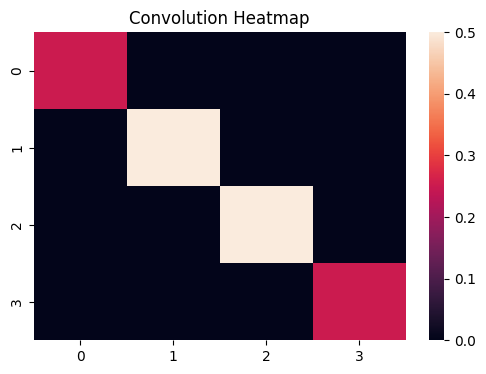

In [4]:
# Manual Full Discrete Convolution
# NOTE: cross-correlation and convolutions do NOT give the same result when the kernel isn't symmetric 

# --- 1D Implementation ---
n, m = 3, 2
x = np.full(n, 1/n, dtype=np.float32) # Input Data
w = np.full(m, 1/n, dtype=np.float32) # Kernel

# since we want to obtain a full convolution, a convolution over all elements, we must pad the input
pad_w = len(w) - 1
x = np.pad(x, pad_w, mode='constant')

# currently, if we proceeded with the convolution logic, we would output an array obtained by
# cross-correlation.
# this is because we haven't flipped the kernel (convo - flip kernel, cross - slide without flipping)

w = w[::-1] # Flip kernel

conv_size = n + pad_w
y = np.zeros(conv_size) # Convolution Output

for i in range(conv_size): 
    y_i = 0
    for j in range(len(w)):
        y_i = y_i + x[i + j] * w[j]
    y[i] = y_i

y = np.round(y, decimals=3)

print(f"Single dimension convolution: {y}\n\n")


# --- 2D Implementation ---
I = np.identity(3)
K = np.array([
    [.25, .0], 
    [.0, .25]
]) # looks for diagonal edges of size 2

ih, iw = I.shape

# since we are completing a 'full' convolution, we will pad the input matrix,
# for each axis (rows x columns), we will pad a total of (kernel_size - 1)

kh, kw = K.shape # (height x width) or (rows x columns)
pad_h = kh - 1
pad_w = kw - 1 # or np.size(K, axis=1) - 1

# how numpy pads -> np.pad(array, ((before_axis0, after_axis0), (before_axis1, after_axis1)))
I_padded = np.pad(I, ((pad_h, pad_h), (pad_w, pad_w)))

# for a true convolution, we must flip the kernel before performing calculations on it,
# ... while we could do this during the convolution (specifically, inner loop), it is much
# ... easier to visualize this way
K_flipped = K[::-1, ::-1]

# Now that we have our padded input (I_padded) and flipped kernel (K_flipped),
# we slide K_flipped over every valid position (i, j) in the output.
#
# At each position (i, j):
#   - extract the local patch of I_padded with the same shape as K_flipped
#   - compute the inner product (elementwise multiply, then sum) of the patch and K_flipped
#   - store the scalar result in output[i, j]
#
# This is the discrete 2D convolution:
#   (I * K)[i,j] = sum_m sum_n I_padded[i+m, j+n] * K_flipped[m, n]
#
# The output shape is (I.shape - K.shape + 1) for valid convolution,
# or (I.shape + K.shape - 1) for full convolution (which we padded for above)

conv_shape = ((ih + kh - 1), (iw + kw - 1))
conv = np.empty(conv_shape)

# Global Convolution (i, j) (Output Conv Size)
for i in range(conv_shape[0]):
    for j in range(conv_shape[1]):

        inner_prod = 0
        # Inner-Local (ki, kj) (patch of kernel in I_padded at i,j)
        for ki in range(kh):
            for kj in range(kw):
                inner_prod += I_padded[i+ki, j+kj] * K_flipped[ki, kj]
        conv[i,j] = inner_prod

reference = scipy.signal.convolve2d(I, K, mode='full')
print(f"Two dimension convolution: \n{conv}")
print(f"reference (scipy convolve2d) check passed: {np.allclose(conv, reference)}")
print(f"starting input: \n{I}, \npadded input: \n{I_padded}")
print(f"starting kernel: \n{K}, \nflipped kernel: \n{K_flipped}")


plt.figure(figsize=(6,4))
sns.heatmap(conv)
plt.title("Convolution Heatmap")
plt.show()


# FFT Convolutions

Before examining FFT Convolutions, let's examine the first part of this: `FFTs`.

#### **Intuition**

If we think about what direct convolution is actually doing mechanically:
for every single output position, you drag the kernel across the input and compute a dot product from scratch.
No work is shared between positions. Every output point pays the full cost independently.

The key question is: **is there a smarter way to compute all of these dot products at once?**

The answer is yes, and the insight comes from a surprising place —
if you look at the signal from a different angle, convolution stops being a sliding dot product
and becomes something much simpler.

**The frequency domain is that angle.**

When you transform a signal into the frequency domain via FFT, you are decomposing it into its
constituent sine waves — each frequency bin tells you how much of that frequency is present in your signal.
In this view, convolution has a remarkably clean interpretation:

> *Each frequency in the input gets scaled by the corresponding frequency in the kernel. Nothing more.*

That scaling is just multiplication — one number times one number, per frequency bin.
No sliding. No dot products. No repeated work.

So instead of paying O(NK) to slide the kernel across every position, you:

1. Pay O(N log N) to transform both signals into frequency domain
2. Pay O(N) to multiply them together bin by bin
3. Pay O(N log N) to transform the result back

Total cost: **O(N log N) — independent of kernel size K.**

A kernel of size 3 and a kernel of size 3000 cost exactly the same in FFT convolution.
That independence from K is the payoff.

---

This works because of the **Convolution Theorem** — a fundamental result that says
convolution in one domain is multiplication in the other:

$$(f * g)(t) \iff F(\omega) \cdot G(\omega)$$

The frequency domain is the *natural home* of convolution.
Multiplication there is what convolution actually is,
and the spatial domain sliding-kernel view is just one way to compute it.

---

___A physical anchor___: think about what a kernel does to a signal intuitively.
A blur kernel suppresses fine detail and preserves coarse structure —
in other words, it **keeps low frequencies and removes high frequencies.**
That is literally just multiplication in the frequency domain:
multiply high frequency bins by a small number, low frequency bins by a large number.
The spatial domain sliding operation and the frequency domain multiplication
are two descriptions of the same transformation.

**What is an FFT?** <br>
The Fast Fourier Transform (FFT) is an algorithm that efficiently computes the Discrete Fourier Transform (DFT).
The DFT transforms a discrete signal from the time/spatial domain into the frequency domain — revealing what 
frequencies are present and at what amplitudes. The FFT computes this in O(N log N) rather than the naive 
O(N²) of the DFT, by recursively exploiting symmetry in the complex exponentials.

Formally, the DFT of a sequence x[n] of length N is:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-i2\pi kn/N}, \quad k = 0, 1, ..., N-1$$

Each X[k] is a complex number encoding the amplitude and phase of frequency k in the signal.
The FFT (Cooley-Tukey, 1965) computes all N of these simultaneously in O(N log N) by splitting 
the DFT into recursive even/odd halves — a divide and conquer strategy on the symmetry of the 
complex exponentials.

**How is it used?** <br>
The FFT produces a frequency-domain representation of a signal. For a real-valued signal of length N: <br>
- The output X[k] has N complex values (or N/2 + 1 unique values via rfft, since the spectrum is conjugate symmetric for real inputs) <br>
- |X[k]| is the magnitude — how much of frequency k is present <br>
- ∠X[k] is the phase — where in the cycle that frequency sits <br>
- The inverse FFT (IFFT) reconstructs the original signal from X[k] exactly <br>

In practice: `np.fft.rfft` for real signals, `np.fft.fft` for complex, `np.fft.ifft` / `np.fft.irfft` to invert.

**When is it used?** <br>
The FFT appears anywhere frequency-domain analysis or fast convolution is needed:

| Domain              | Use                                                    |
|---------------------|--------------------------------------------------------|
| Signal processing   | Spectral analysis, filtering, noise removal            |
| Audio               | STFT for MFCCs, pitch detection, compression (MP3)    |
| Images              | JPEG compression, frequency-domain filtering           |
| Scientific computing| Solving PDEs spectrally, fast polynomial multiplication|
| Deep learning       | FFT convolution, Fourier Neural Operator (FNO)         |
| Communications      | OFDM modulation, channel estimation                    |

The crossover point where FFT beats direct computation is roughly when N log N < NK — 
i.e., when the kernel size K > log N. For large kernels or long signals, FFT wins decisively.

**How does it affect convolutions?** <br>
This is the payoff. The Convolution Theorem states:

$$(f * g)(t) \iff F(\omega) \cdot G(\omega)$$

Convolution in the spatial/time domain is pointwise multiplication in the frequency domain. <br>
This means instead of the O(N²) direct convolution, we can:

1. FFT both signals:         O(N log N) <br>
2. Pointwise multiply:       O(N) <br>
3. Inverse FFT:              O(N log N) <br>

Total: **O(N log N)** — independent of kernel size.

This isn't an approximation. It is mathematically exact (up to floating point), just a 
different computational path to the same result. The frequency domain is the natural home 
of convolution — multiplication there is what convolution *is*. <br>

One implementation detail: the DFT assumes periodicity, so naive FFT convolution computes 
*circular* convolution, not linear. The fix is zero-padding both input and kernel to length 
N + K - 1 before transforming — eliminating wraparound artifacts entirely.

---

**FFT Convolution Form** <br>
From the base convolution theorem we can surmise, given two signals $f$ and $g$, the FFT convolution is computed as:

$$(f * g) = \mathcal{F}^{-1}\{\mathcal{F}\{f\} \cdot \mathcal{F}\{g\}\}$$

Where $\mathcal{F}$ and $\mathcal{F}^{-1}$ denote the FFT and inverse FFT respectively. <br>
Expanded into the explicit pipeline:

$$\text{conv}(f, g)[n] = \text{IFFT}(\text{FFT}(f) \cdot \text{FFT}(g))[n]$$

Reference check matches: True


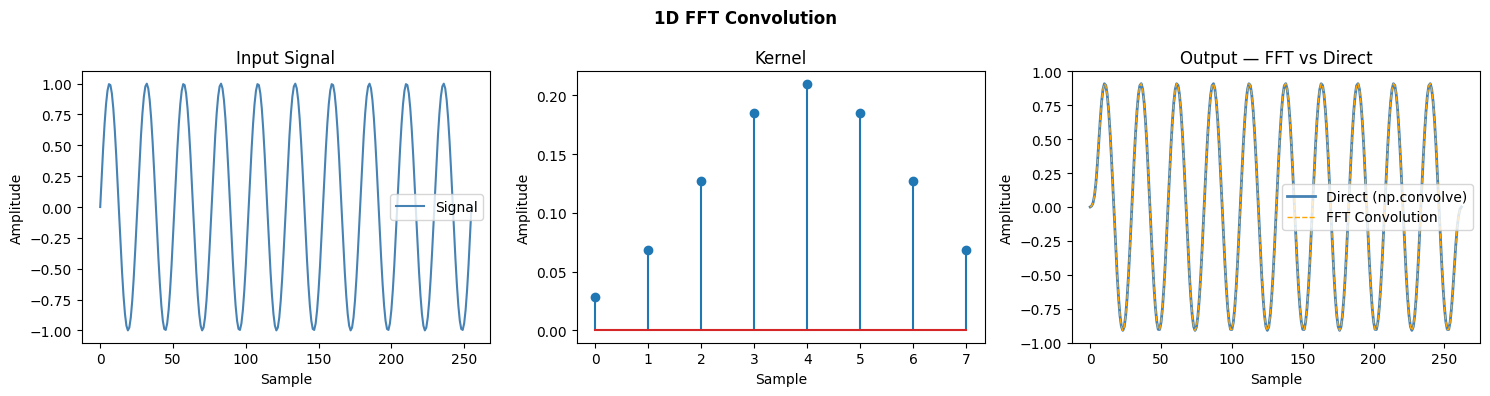

In [5]:
# FFT Convolution (1D - manual implementation)

# We have our manual convolution implementation above — now lets see how FFT changes things.
# Instead of sliding the kernel across every position, we transform both signals to frequency
# domain, multiply pointwise, and transform back. Same result, fraction of the cost.

# NOTE: padding to n + k - 1 is non-negotiable — without it the DFT assumes periodicity
# and the kernel wraps around the edges (circular convolution), corrupting the output.
# Zero padding breaks the wraparound by buffering the end of the signal.

def next_power_of_2(n):
    return 1 << (n - 1).bit_length()  # smallest 2^k >= n

def fft_convolve_1d(f, g):
    # 1. compute minimum output length — prevents circular convolution
    n_linear = len(f) + len(g) - 1
    
    # 2. pad to next power of 2 for FFT efficiency
    n_fft    = next_power_of_2(n_linear)
    f_padded = np.pad(f, (0, n_fft - len(f)))
    g_padded = np.pad(g, (0, n_fft - len(g)))
    
    # 3. FFT both signals into frequency domain
    F = np.fft.rfft(f_padded)
    G = np.fft.rfft(g_padded)
    
    # 4. pointwise multiply — this IS the convolution in frequency domain
    H = F * G
    
    # 5. inverse FFT back to time domain, trim to valid length
    result = np.fft.irfft(H, n=n_fft)
    return result[:n_linear]

# Example Usage - sampling from a sine wave
n = 256    # number of samples
sr = 128   # sampling rate (Hz) - samples per second
f = 5      # frequency (Hz)
amp = 1.0  # amplitude

t = np.linspace(0, n/sr, n)          # time axis - sample N points along (0, N/sr)
S = amp * np.sin(2 * np.pi * f * t)  # signal - sampled sine wave

ksize = 8
K = np.arange(ksize) - ksize // 2  # centered at zero
K = np.exp(-0.5 * (K / 2.0)**2)    # gaussian shape
K = K / K.sum()                    # normalized kernel

conv = fft_convolve_1d(S, K)

# Compare against scipy
ref = scipy.signal.fftconvolve(S, K, mode='full')
if np.allclose(conv, ref):
    print("Reference check matches: True")
else:
    print("Reference check matches: False")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("1D FFT Convolution", fontweight='bold')

# Input Signal 
axes[0].plot(S, label='Signal', color='steelblue')
axes[0].set_title("Input Signal")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

# Kernel 
axes[1].stem(range(len(K)), K)
axes[1].set_title("Kernel")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Amplitude")

# FFT vs Reference 
axes[2].plot(ref, label='Direct (np.convolve)', linewidth=2, color='steelblue')
axes[2].plot(conv, label='FFT Convolution', linewidth=1, linestyle='--', color='orange')
axes[2].set_title("Output — FFT vs Direct")
axes[2].set_xlabel("Sample")
axes[2].set_ylabel("Amplitude")
axes[2].legend()

plt.tight_layout()
plt.show()

# 2D FFT Convolution

--- 

The 1D FFT convolution extends naturally to 2D — the pipeline is identical,
the only difference is that we now operate on matrices instead of vectors,
and apply the FFT along both axes. <br><br>

The 2D convolution of an image $F$ and kernel $G$ is:

$$(F * G) = \mathcal{F}^{-1}_{2D}\{\mathcal{F}_{2D}\{F\} \cdot \mathcal{F}_{2D}\{G\}\}$$

Where $\mathcal{F}_{2D}$ and $\mathcal{F}^{-1}_{2D}$ denote the 2D FFT and inverse 2D FFT. <br><br>

**Pipeline:** <br>
1. Zero pad both input and kernel to shape $(N + K_h - 1, \ M + K_w - 1)$ — prevents circular convolution along both axes <br>
2. 2D FFT both — transforms rows then columns, O(NM log NM) <br>
3. Pointwise multiply in frequency domain <br>
4. Inverse 2D FFT — back to spatial domain <br>
5. Trim to valid output shape <br><br>

**Output shape:** <br>
- Valid convolution: $(N - K_h + 1, \ M - K_w + 1)$ — smaller than input <br>
- Full convolution: $(N + K_h - 1, \ M + K_w - 1)$ — larger than input <br><br>

**Common 2D kernels and their effects:**

| Kernel | Effect | Frequency Domain |
|---|---|---|
| Gaussian | Smoothing / blur | Suppresses high frequencies |
| Box / average | Uniform blur | Low pass filter |
| Sobel | Edge detection | Enhances high frequencies |
| Sharpen | Edge enhancement | Boosts high frequencies |
| Identity | No change | Flat response — all frequencies pass |

**Why 2D FFT convolution matters:** <br>
For large kernels the cost advantage is the same as 1D — O(NM log NM) vs O(NM $K_h K_w$).
A 64×64 kernel on a 512×512 image would require ~1 billion operations directly.
Via FFT that drops to ~2 million. The larger the kernel relative to the image, the more FFT wins. <br><br>

The 2D FFT is computed by applying the 1D FFT along rows first, then along columns —
separability of the transform means the 2D case is just two passes of the 1D case.
This is why `np.fft.fft2` exists as a convenience wrapper and not a fundamentally different algorithm.

Reference check matches: True


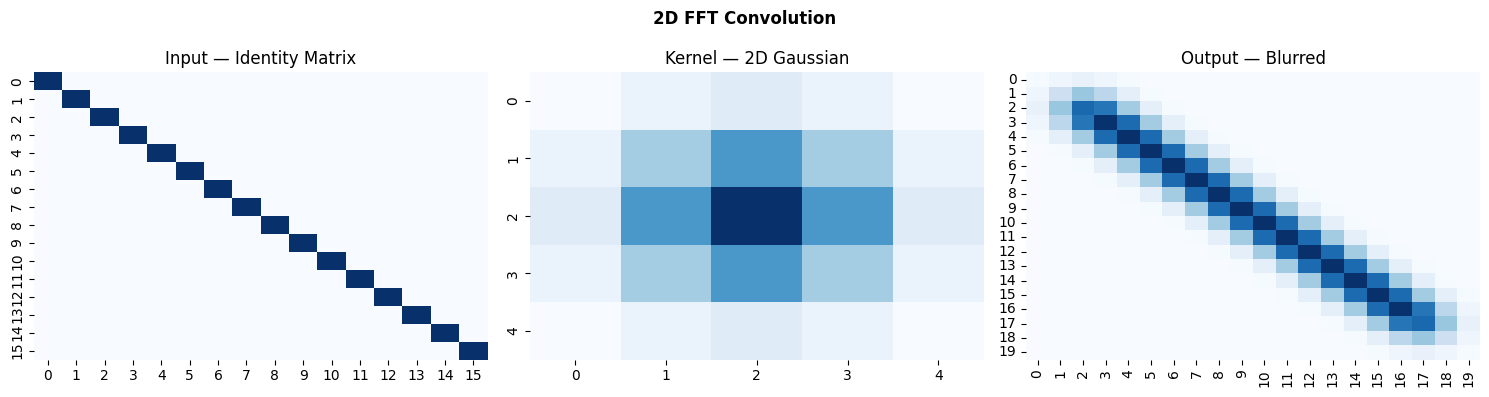

In [6]:
# FFT Convolution (2D)

# 1D works — extending to 2D is straightforward, same pipeline just operating on matrices.
# The main difference: we now pad and transform along both axes independently,
# and our output is a matrix instead of a vector. np.fft.rfft2 handles the 2D transform,
# everything else is the same logic.

def fft_convolve_2d(F, G):
    # 1. compute output shape — pad by kernel size - 1 on each axis
    out_h    = F.shape[0] + G.shape[0] - 1
    out_w    = F.shape[1] + G.shape[1] - 1
    
    # 2. pad both to next power of 2 on each axis
    n_fft_h  = next_power_of_2(out_h)
    n_fft_w  = next_power_of_2(out_w)

    f_padded = np.pad(F, ((0, n_fft_h - F.shape[0]), (0, n_fft_w - F.shape[1])))
    g_padded = np.pad(G, ((0, n_fft_h - G.shape[0]), (0, n_fft_w - G.shape[1])))

    # 3. 2D FFT both — applies FFT along rows then columns
    F_freq   = np.fft.rfft2(f_padded)
    G_freq   = np.fft.rfft2(g_padded)

    # 4. pointwise multiply in frequency domain
    H        = F_freq * G_freq

    # 5. inverse 2D FFT, trim to valid output shape
    result   = np.fft.irfft2(H, s=(n_fft_h, n_fft_w))
    return result[:out_h, :out_w]

# Example Usage - 2D FFT Convolution on a simple image
I = np.eye(16)                               # input - 16x16 identity matrix
# Gaussian kernel - 5x5, sigma=1.0
ksize = 5
k     = np.arange(ksize) - ksize // 2       # centered at zero
K1d   = np.exp(-0.5 * (k / 1.0)**2)         # gaussian shape
K2d   = np.outer(K1d, K1d)                  # outer product — 2D gaussian
K2d   = K2d / K2d.sum()                     # normalized kernel

conv2d = fft_convolve_2d(I, K2d)

# Compare against scipy
ref2d = scipy.signal.fftconvolve(I, K2d, mode='full')
if np.allclose(conv2d, ref2d):
    print("Reference check matches: True")
else:
    print("Reference check matches: False")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("2D FFT Convolution", fontweight='bold')

# Input
sns.heatmap(I,      ax=axes[0], cmap='Blues', cbar=False)
axes[0].set_title("Input — Identity Matrix")

# Kernel
sns.heatmap(K2d,    ax=axes[1], cmap='Blues', cbar=False)
axes[1].set_title("Kernel — 2D Gaussian")

# Output
sns.heatmap(conv2d, ax=axes[2], cmap='Blues', cbar=False)
axes[2].set_title("Output — Blurred")

plt.tight_layout()
plt.show()

     N |   Manual (s) |    FFT (s) |    Speedup
------------------------------------------------
     8 |     0.002003 |   0.001998 |      1.00x
    16 |     0.004167 |   0.002998 |      1.39x
    32 |     0.011324 |   0.000000 |       infx
    64 |     0.029998 |   0.001502 |     19.97x
   128 |     0.128038 |   0.003041 |     42.11x
   256 |     0.495919 |   0.011038 |     44.93x
   512 |     2.004861 |   0.056498 |     35.49x


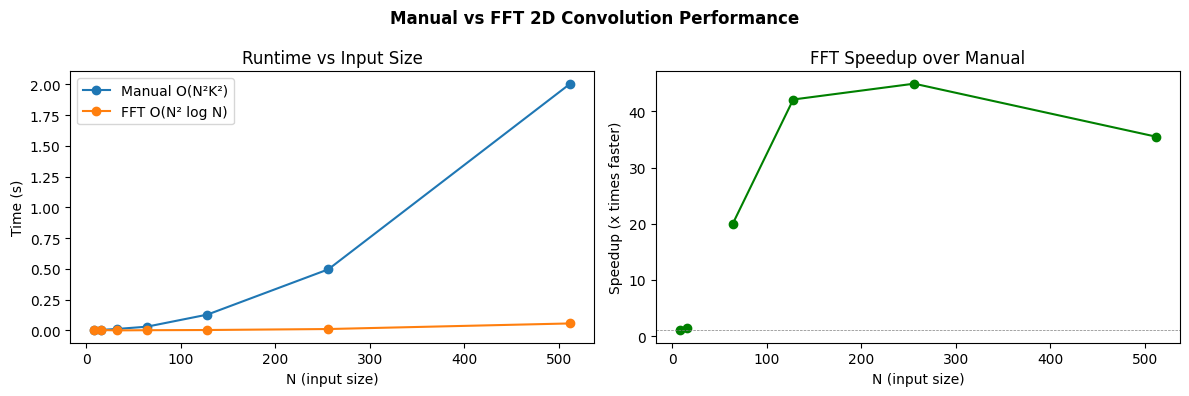

In [7]:
# Performance comparison between vanilla discrete convolve vs fft convolve

sizes   = [8, 16, 32, 64, 128, 256, 512]
results = []

print(f"{'N':>6} | {'Manual (s)':>12} | {'FFT (s)':>10} | {'Speedup':>10}")
print("-" * 48)

for N in sizes:
    I      = np.random.randn(N, N)
    K      = np.random.randn(3, 3)  # fixed 3x3 kernel

    # --- Manual conv ---
    timer.set()
    kh, kw    = K.shape
    pad_h     = kh - 1
    pad_w     = kw - 1
    I_padded  = np.pad(I, ((pad_h, pad_h), (pad_w, pad_w)))
    K_flipped = K[::-1, ::-1]
    out_shape = (I.shape[0] + pad_h, I.shape[1] + pad_w)
    conv_out  = np.empty(out_shape)
    for i in range(out_shape[0]):
        for j in range(out_shape[1]):
            conv_out[i,j] = np.sum(I_padded[i:i+kh, j:j+kw] * K_flipped)
    t_manual = timer.stop()

    # --- FFT conv ---
    timer.set()
    fft_convolve_2d(I, K)
    t_fft = timer.stop()

    speedup = t_manual / t_fft if t_fft > 0 else float('inf')
    print(f"{N:>6} | {t_manual:>12.6f} | {t_fft:>10.6f} | {speedup:>9.2f}x")
    results.append((N, t_manual, t_fft, speedup))

# %%timeit fft_convolve_1d(I, K)

# --- Plot ---
Ns       = [r[0] for r in results]
t_manual = [r[1] for r in results]
t_ffts   = [r[2] for r in results]
speedups = [r[3] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Manual vs FFT 2D Convolution Performance", fontweight='bold')

axes[0].plot(Ns, t_manual, marker='o', label='Manual O(N²K²)')
axes[0].plot(Ns, t_ffts,   marker='o', label='FFT O(N² log N)')
axes[0].set_title("Runtime vs Input Size")
axes[0].set_xlabel("N (input size)")
axes[0].set_ylabel("Time (s)")
axes[0].legend()

axes[1].plot(Ns, speedups, marker='o', color='green')
axes[1].set_title("FFT Speedup over Manual")
axes[1].set_xlabel("N (input size)")
axes[1].set_ylabel("Speedup (x times faster)")
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Probabilistic Convolutions

If $X$ and $Y$ are independent random variables, the PDF of their sum $Z = X + Y$ 
is the convolution of their individual PDFs:

$$p_Z(z) = (p_X * p_Y)(z) = \int p_X(\tau) \cdot p_Y(z - \tau) \, d\tau$$

This is the same sliding multiply-and-sum operation as signal convolution — 
just applied to probability distributions instead of signals. <br><br>

**Classic result:** the sum of two Gaussians is a Gaussian:

$$\mathcal{N}(\mu_1, \sigma_1^2) * \mathcal{N}(\mu_2, \sigma_2^2) = \mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$$

This is also why the **Central Limit Theorem** works — repeated convolution of any 
distribution converges to Gaussian.

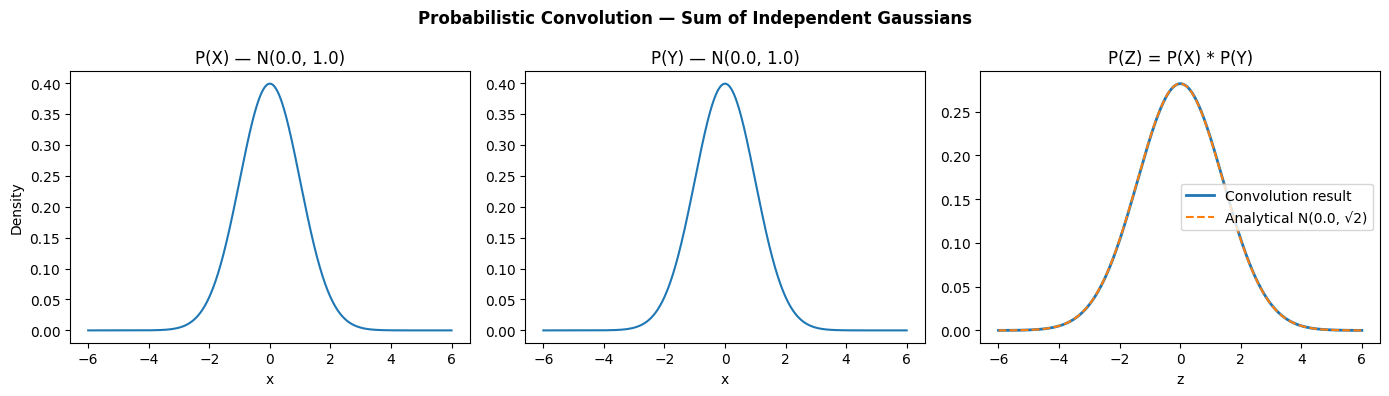

Max error vs analytical: 0.000727


In [8]:
# Probabilistic Convolution 

# If X ~ P and Y ~ Q are independent random variables,
# the PDF of their sum Z = X + Y is the convolution of their PDFs:
#
#   p_Z(z) = (p_X * p_Y)(z) = integral p_X(t) p_Y(z-t) dt
#
# Classic result: Gaussian * Gaussian = Gaussian
# N(mu1, sigma1) * N(mu2, sigma2) = N(mu1+mu2, sqrt(sigma1^2 + sigma2^2))
# This is also why the Central Limit Theorem works — repeated convolution
# of any distribution converges to Gaussian.

from scipy.stats import norm

z     = np.linspace(-6, 6, 1000)

# two gaussians
mu1, sigma1 = 0.0, 1.0
mu2, sigma2 = 0.0, 1.0

p1 = norm.pdf(z, mu1, sigma1)   # N(0, 1)
p2 = norm.pdf(z, mu2, sigma2)   # N(0, 1)

# convolve PDFs — result should be N(0, sqrt(2))
dz           = z[1] - z[0]
p_conv       = np.convolve(p1, p2, mode='same') * dz  # scale by dz to approximate integral
p_analytical = norm.pdf(z, mu1+mu2, np.sqrt(sigma1**2 + sigma2**2))  # N(0, sqrt(2))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Probabilistic Convolution — Sum of Independent Gaussians", fontweight='bold')

axes[0].plot(z, p1)
axes[0].set_title(f"P(X) — N({mu1}, {sigma1})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")

axes[1].plot(z, p2)
axes[1].set_title(f"P(Y) — N({mu2}, {sigma2})")
axes[1].set_xlabel("x")

axes[2].plot(z, p_conv,       label='Convolution result', linewidth=2)
axes[2].plot(z, p_analytical, label=f'Analytical N({mu1+mu2}, √{sigma1**2+sigma2**2:.0f})', linestyle='--')
axes[2].set_title("P(Z) = P(X) * P(Y)")
axes[2].set_xlabel("z")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Max error vs analytical: {np.max(np.abs(p_conv - p_analytical)):.6f}")

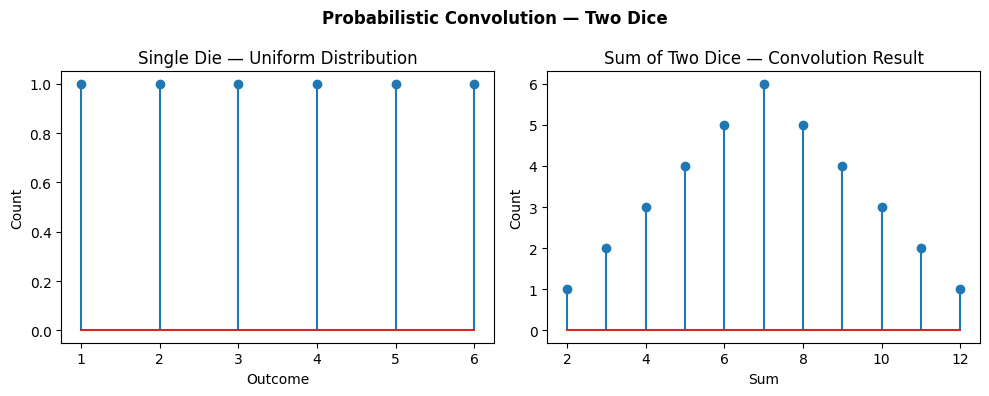

In [9]:
# Probabilistic Convolution — Sum of Two Dice

# As a similar example was shown above in the manual convolution section, we can see that:
# Each die is uniform over {1,2,3,4,5,6} — equal probability for each face
# The distribution of their sum is the convolution of the two uniform distributions
# Result: triangle shape peaking at 7 — the most likely sum

outcomes = np.ones(6)          # uniform distribution — each face equally likely

conv = np.convolve(outcomes, outcomes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Probabilistic Convolution — Two Dice", fontweight='bold')

axes[0].stem(range(1, 7), outcomes)
axes[0].set_title("Single Die — Uniform Distribution")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Count")

axes[1].stem(range(2, 13), conv)
axes[1].set_title("Sum of Two Dice — Convolution Result")
axes[1].set_xlabel("Sum")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Convolution Optimizations

#### Convolutions are Embarrassingly Parallel
Every output element `conv[i,j]` is computed independently — no output depends on any other.
This makes convolution a natural candidate for parallelism at multiple levels. <br><br>

> **Keep in mind** that parallelism only pays off above a certain threshold. <br>
> For small inputs and kernels, serial CPU code wins — the overhead of spawning threads or 
> moving data to a GPU dominates the actual compute time. <br>
> The crossover point depends on input size, kernel size, and hardware.

**Levels of parallelism available:**
- **CPU threading** — parallelize outer loops across cores via OpenMP or Python multiprocessing
- **SIMD** — process multiple elements simultaneously via AVX/SSE vector instructions
- **GPU / CUDA** — map each output element to a thread, thousands of elements computed simultaneously
- **FFT** — algorithmic parallelism, reduces complexity from O(N²K²) to O(N log N) regardless of hardware

The cells below demonstrate CPU-level parallelism via Python multiprocessing — 
the same embarrassingly parallel structure that makes CUDA convolution so effective.



In [ ]:
# Parallel Optimization of 2D Convolutions 

# Convolution is embarrassingly parallel — every output element conv[i,j] is independent,
# no output depends on another. This makes it a perfect candidate for parallelization.
# Here we use Python's multiprocessing to parallelize the outer loop across CPU cores.

# NOTE: Python's GIL (Global Interpreter Lock) allows only one thread to execute at a time,
# and while this allows for the dynamic and fluid nature of Python's variables and memory
# management, it makes true CPU-level thread parallelism impossible within a single process.
# For CPU-bound work like convolution, we use multiprocessing instead — spawning separate
# processes each with their own GIL and memory space. The tradeoff is process spawn overhead
# and data serialization costs, which is why parallelism only pays off above a certain input size.


# Pool creates N worker processes upfront — like pre-forking
# with Pool(4) as pool:        # 4 worker processes
#     results = pool.map(f, items)  # distribute work across them

# NOTE: multiprocessing.Pool requires the if __name__ == '__main__' guard for process
# spawning which Jupyter cannot provide — running this cell will cause the kernel to hang.
# To run this implementation, copy the functions to a .py file and execute directly:
#
#   python parallel_conv.py
#
# The implementation is correct — the limitation is the notebook environment, not the code.

# --- uncomment to run ---
# !python -c "
# import numpy as np
# import os
# import scipy.signal
# from multiprocessing import Pool
# import matplotlib.pyplot as plt
# import seaborn as sns

# def conv_row(args):
#     # compute one row of the convolution output
#     i, conv_shape, I_padded, K_flipped = args
#     kh, kw = K_flipped.shape
#     row = np.zeros(conv_shape[1])
    
#     # compute inner-product at conv_output index (i, j) for all kh x kw
#     for j in range(conv_shape[1]):
#         # inner = 0.0
#         # for kh in range(K_flipped.shape[0]):
#         #     for kw in range(K_flipped.shape[1]):
#         #         inner = I_padded[i + kh, j + kw] * K_flipped[i + kh, j + kw]
#         patch = I_padded[i:i+kh, j:j+kw]
#         row[j] = patch.ravel() @ K_flipped.ravel() # inner-product (dot product as vectors)

#     return row

# def conv2d_parallel(I, K):
#     ih, iw = I.shape
#     kh, kw = K.shape
#     K_flipped = K[::-1, ::-1]
    
#     pad_h = kh - 1
#     pad_w = kw - 1

#     I_padded = np.pad(I, ((pad_h, pad_h), (pad_w, pad_w)))

#     conv_shape = (ih + kh - 1, iw + kw - 1)

#     args = [(i, conv_shape, I_padded, K_flipped) for i in range(conv_shape[0])] 
    
#     n_cpu = os.cpu_count()
#     with Pool(n_cpu) as pool:
#         results = pool.map(conv_row, args)

#     output = np.zeros(conv_shape)
#     for i, row in enumerate(results):
#         output[i] = row
    
#     return output


# # Example Usage
# if __name__ == '__main__':
#     N  = 32
#     I  = np.eye(N)
#     K  = np.array([[0, -1,  0],
#                    [-1, 4, -1],
#                    [0, -1,  0]], dtype=float)  # edge detection kernel
    
#     output = conv2d_parallel(I, K)
#     print(output)
#     ref = scipy.signal.convolve2d(I, K, mode='full')
    
#     print(f"Reference check matches: {np.allclose(output, ref)}") 
    
#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     fig.suptitle("Parallel 2D Convolution", fontweight='bold')
    
#     sns.heatmap(I, ax=axes[0], cmap='Blues', cbar=False)
#     axes[0].set_title("Input")
    
#     sns.heatmap(K, ax=axes[1], cmap='Blues', cbar=False)
#     axes[1].set_title("Kernel — Edge Detection")
    
#     sns.heatmap(output, ax=axes[2], cmap='Blues', cbar=False)
#     axes[2].set_title("Output")
    
#     plt.tight_layout()
#     plt.show() "


In [ ]:
# !python parallel_conv.py

# Reference Notes

--- 

## Convolution Reference

### 1. Discrete 1D Convolution

Discrete convolution between signals $x$ and $h$:

$$
y[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k]
$$

Practical finite version:

$$
y[n] = \sum_{k=0}^{K-1} x[k]\,h[n-k]
$$

Where:

- $x$ = input signal  
- $h$ = kernel / filter  
- $y$ = output signal  


---

### 2. Discrete 2D Convolution (Images)

For images:

$$
S(i,j) = \sum_m \sum_n I(m,n)\,K(i-m, j-n)
$$

Where:

- $I$ = input image  
- $K$ = convolution kernel  
- $S$ = output feature map  


---

### 3. Cross-Correlation (Used in CNNs)

Many ML libraries implement **cross-correlation** instead of strict convolution:

$$
S(i,j) = \sum_m \sum_n I(i+m, j+n)\,K(m,n)
$$

Difference:

- **Convolution** flips the kernel
- **Cross-correlation** does not


---

### 4. Convolution Theorem (FFT Convolution)

Convolution can be computed in the frequency domain:

$$
x * h = \mathcal{F}^{-1}\left(\mathcal{F}(x)\cdot\mathcal{F}(h)\right)
$$

Meaning:

$$
\text{convolution in time/space} =
\text{multiplication in frequency domain}
$$

Algorithm:

1. Compute FFT of both signals
2. Multiply in frequency domain
3. Apply inverse FFT


---

### 5. Discrete Fourier Transform (DFT)

Forward transform:

$$
X[k] = \sum_{n=0}^{N-1} x[n]\,e^{-i2\pi kn/N}
$$

Inverse transform:

$$
x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]\,e^{i2\pi kn/N}
$$

FFT is a **fast algorithm for computing the DFT**.


---

### 6. Computational Complexity

Direct convolution:

$$
O(N^2)
$$

FFT-based convolution:

$$
O(N\log N)
$$


---

### 7. Convolution of Probability Distributions

If $X$ and $Y$ are independent random variables:

$$
P(Z=n) = \sum_k P(X=k)\,P(Y=n-k)
$$

This is exactly the **convolution of two probability distributions**.

Example: the probability distribution of the **sum of two dice**.

---

In [4]:
# Inner product performance tests (numpy)
import timeit

patch     = np.random.randn(3, 3)
K_flipped = np.random.randn(3, 3)

t1 = timeit.timeit(lambda: patch.ravel() @ K_flipped.ravel(), number=100000)
t2 = timeit.timeit(lambda: np.sum(patch * K_flipped),         number=100000)
t3 = timeit.timeit(lambda: np.dot(patch.ravel(), K_flipped.ravel()), number=100000)

print(f"ravel + @:        {t1:.4f}s")
print(f"sum * :           {t2:.4f}s")
print(f"ravel + np.dot:   {t3:.4f}s")

ravel + @:        0.1827s
sum * :           0.4681s
ravel + np.dot:   0.1419s
